Install Libraries & Imports

In [13]:
# Verify environment
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
else:
    print(" No GPU detected — training will be slow!")

PyTorch version: 2.10.0+cu126
CUDA available: True
GPU device: NVIDIA GeForce RTX 4060 Laptop GPU


In [30]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported")

 All libraries imported


Load Dataset

In [23]:
train_df = pd.read_csv('../data/train.csv')
val_df = pd.read_csv('../data/val.csv')
test_df = pd.read_csv('../data/test.csv')

X_train, y_train = train_df['clean_tweet'], train_df['class']
X_val, y_val = val_df['clean_tweet'], val_df['class']
X_test, y_test = test_df['clean_tweet'], test_df['class']

Tokenizer & Data Loader

In [42]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts.values
        self.labels = labels.values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

# DataLoader 
train_loader = DataLoader(TweetDataset(X_train, y_train, tokenizer), batch_size=16, shuffle=True)
val_loader = DataLoader(TweetDataset(X_val, y_val, tokenizer), batch_size=16)
test_loader = DataLoader(TweetDataset(X_test, y_test, tokenizer), batch_size=16, shuffle=False) 
# no shuffling for test set

Model, Weighted Loss & Optimizer

In [43]:
# handle class imbalance in weights
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

print(f"Calculated weights: {weights}")

Calculated weights: [5.77651515 0.43048227 1.98448448]


In [44]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load Model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
).to(device)

# Loss function
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5)

# Use Scheduler to prevent overfitting
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=len(train_loader)*4)

Using device: cuda


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8775.43it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training & Evaluation Functions + Training Loop

In [45]:
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}
epochs = 4

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs}")
    print("-" * 20)
    
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0
    correct_train = 0
    
    for batch in tqdm(train_loader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        # Forward pass
        outputs = model(input_ids, attention_mask=attention_mask)
        # Calculate loss using your weighted loss function
        loss = loss_fn(outputs.logits, labels) 
        # Backward pass & Optimization
        loss.backward()
        # Gradient clipping is recommended for Transformers to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step() # Update learning rate according to schedule 
        optimizer.zero_grad()

        total_train_loss += loss.item()
        _, preds = torch.max(outputs.logits, dim=1)
        correct_train += torch.sum(preds == labels)

    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_acc = correct_train.double() / len(X_train)
    
    # --- VALIDATION PHASE ---
    model.eval()
    total_val_loss = 0
    correct_val = 0
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)

            total_val_loss += loss.item()
            _, preds = torch.max(outputs.logits, dim=1)
            correct_val += torch.sum(preds == labels)

    avg_val_loss = total_val_loss / len(val_loader)
    avg_val_acc = correct_val.double() / len(X_val)

    # Print epoch summary
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f}")

    # Store metrics for plotting Figure 3
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc.item())
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc.item())


Epoch 1/4
--------------------


Validation: 100%|██████████| 155/155 [00:05<00:00, 29.80it/s]


Train Loss: 0.5941 | Train Acc: 0.8700
Val Loss: 0.4852 | Val Acc: 0.9076

Epoch 2/4
--------------------


Validation: 100%|██████████| 155/155 [00:04<00:00, 31.16it/s]


Train Loss: 0.4499 | Train Acc: 0.9107
Val Loss: 0.4494 | Val Acc: 0.8890

Epoch 3/4
--------------------


Validation: 100%|██████████| 155/155 [00:05<00:00, 29.72it/s]


Train Loss: 0.3511 | Train Acc: 0.9324
Val Loss: 0.5930 | Val Acc: 0.9072

Epoch 4/4
--------------------


Validation: 100%|██████████| 155/155 [00:05<00:00, 29.92it/s]

Train Loss: 0.2701 | Train Acc: 0.9524
Val Loss: 0.6908 | Val Acc: 0.9048


Plot Training Curves

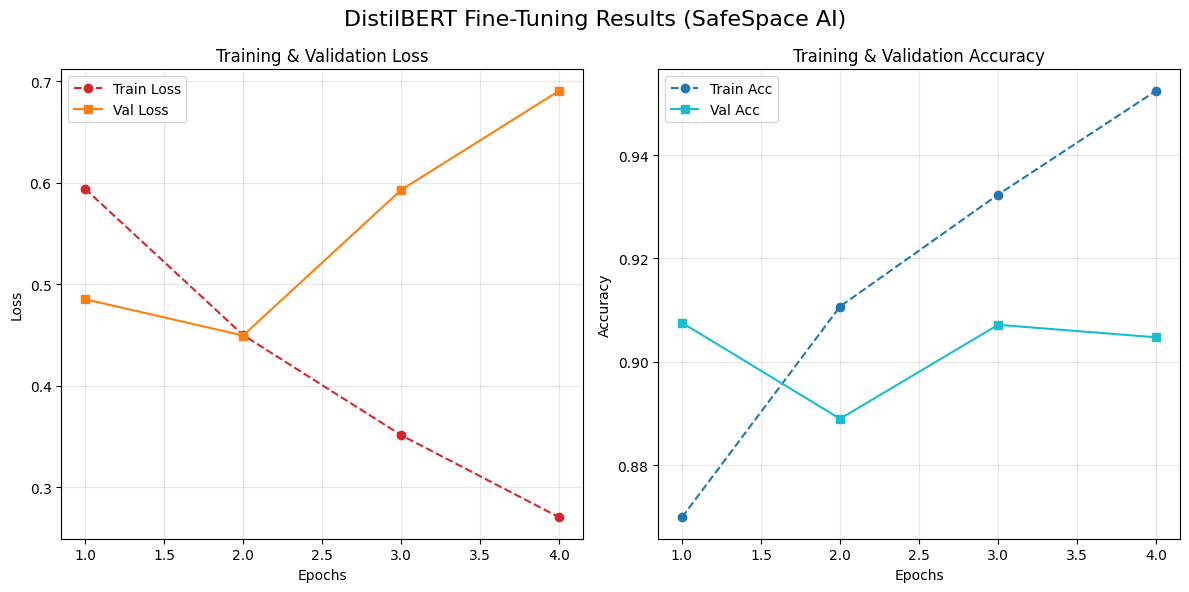

In [51]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Loss Curve (Left)
    ax1.plot(range(1, 5), history['train_loss'], label='Train Loss', color='tab:red', marker='o', linestyle='--')
    ax1.plot(range(1, 5), history['val_loss'], label='Val Loss', color='tab:orange', marker='s')
    ax1.set_title('Training & Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy Curve (Right)
    ax2.plot(range(1, 5), history['train_acc'], label='Train Acc', color='tab:blue', marker='o', linestyle='--')
    ax2.plot(range(1, 5), history['val_acc'], label='Val Acc', color='tab:cyan', marker='s')
    ax2.set_title('Training & Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle('DistilBERT Fine-Tuning Results (SafeSpace AI)', fontsize=16)
    plt.tight_layout()
    
    # save the plot
    plt.savefig('../src/training_curves.png')

    plt.show()

plot_training_history(history)

Final Test Evaluation & Confusion Matrix

In [54]:
model.eval()
y_preds = []
y_true = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Predict
        outputs = model(input_ids, attention_mask=attention_mask)
        
        # Get the predicted class
        _, preds = torch.max(outputs.logits, dim=1)
        
        y_preds.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

print("Classification Report (Transformer):")
print(classification_report(y_true, y_preds))

Classification Report (Transformer):
              precision    recall  f1-score   support

           0       0.47      0.49      0.48       143
           1       0.95      0.94      0.95      1919
           2       0.89      0.91      0.90       417

    accuracy                           0.91      2479
   macro avg       0.77      0.78      0.78      2479
weighted avg       0.91      0.91      0.91      2479



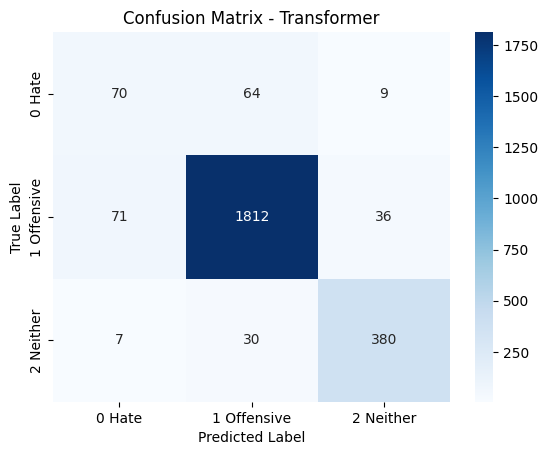

In [59]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_preds)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 Hate', '1 Offensive', '2 Neither'],
            yticklabels=['0 Hate', '1 Offensive', '2 Neither'])
plt.title('Confusion Matrix - Transformer')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.savefig('../src/confusion_matrix_transformer.png')
plt.show()

Confidence Analysis

In [60]:
import torch.nn.functional as F

model.eval()
all_confidences = []
all_correct = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        
        probs = F.softmax(outputs.logits, dim=1)
        
        # get the predicted class and its confidence score
        conf, preds = torch.max(probs, dim=1)
        
        all_confidences.extend(conf.cpu().numpy())
        all_correct.extend((preds == labels).cpu().numpy())

all_confidences = np.array(all_confidences)
all_correct = np.array(all_correct)

In [61]:
thresholds = np.linspace(0.5, 0.95, 10)
accuracies = []
coverages = []

for t in thresholds:
    # find the indices where the confidence is greater than or equal to the threshold
    mask = all_confidences >= t
    if np.any(mask):
        acc = np.mean(all_correct[mask])
        cov = np.mean(mask)
        accuracies.append(acc)
        coverages.append(cov)
    else:
        accuracies.append(None)
        coverages.append(0)

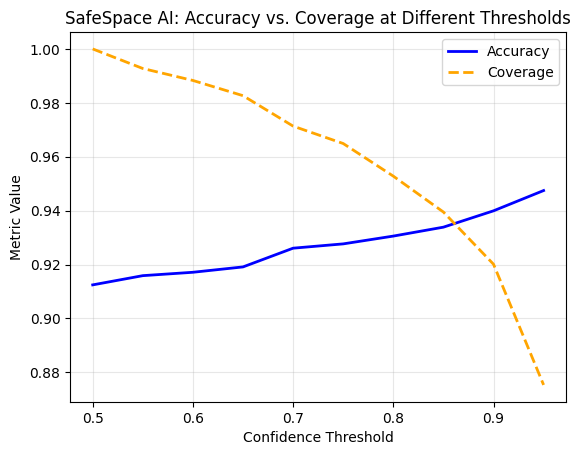

In [63]:
plt.figure()
plt.plot(thresholds, accuracies, label='Accuracy', color='blue', linewidth=2)
plt.plot(thresholds, coverages, label='Coverage', color='orange', linestyle='--', linewidth=2)

plt.xlabel('Confidence Threshold')
plt.ylabel('Metric Value')
plt.title('SafeSpace AI: Accuracy vs. Coverage at Different Thresholds')
plt.legend()
plt.grid(True, alpha=0.3)

# save the plot
plt.savefig('../src/confidence_analysis_plot.png')
plt.show()